In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/Net/Groups/BSI/work_scratch/ppapastefanou/data/Fluxnet_detail/raw/florapulse-2023-2024.csv")

In [3]:
df["date"] = pd.to_datetime(df["timestamp"])

In [24]:
filtered_df = df[df['id'].str.contains("beech_2_s", na=False)]
filtered_df.dropna(inplace=True)
filtered_df = filtered_df[(filtered_df['psi'] >= -40) & (filtered_df['psi'] <= 0)]
filtered_df['psi'] *= 0.1 # from bar to MPa

#filtered_df = filtered_df[(filtered_df['date'] >=  '2024-07-1')& (filtered_df['date'] <= '2024-09-8')]
filtered_df = filtered_df[(filtered_df['date'] <= '2024-09-11')]
filtered_df['date'] = filtered_df['date'].dt.tz_localize(None)
filtered_df.sort_values(by='date', ascending=True, inplace=True)
filtered_df.set_index('date', inplace=True)
filtered_df.dropna(inplace=True)
resampled_df = filtered_df.resample('30min').mean(numeric_only=True)

resampled_df['hour'] = resampled_df.index.hour
resampled_df['minute'] = resampled_df.index.minute

# 2. Group by hour and minute to get the "Average Day"
average_day = resampled_df.groupby(['hour', 'minute'])['psi'].mean().reset_index()

/tmp/ipykernel_1000896/4097588011.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df.dropna(inplace=True)


In [25]:
resampled_df.dropna(inplace=True)

In [26]:
import matplotlib.pyplot as plt
import numpy as np

Text(0.5, 1.0, 'Average Diurnal Cycle')

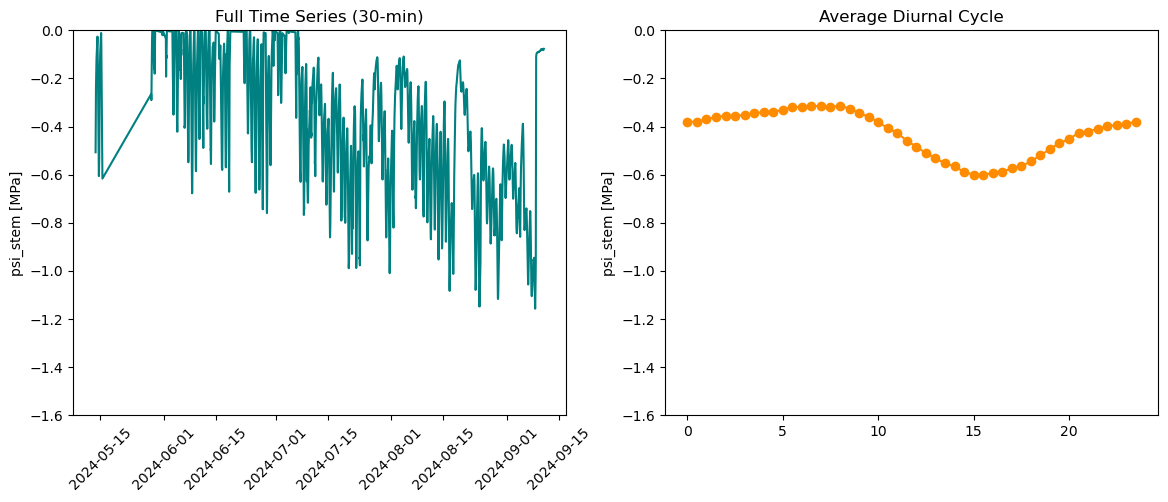

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


ax1.plot(resampled_df.index, resampled_df['psi'], color='teal')
ax1.set_ylim(-1.6, 0)
ax1.set_ylabel("psi_stem [MPa]")
ax1.set_title("Full Time Series (30-min)")
ax1.tick_params(axis='x', rotation=45)


ax2.plot(np.arange(0,24, 0.5), average_day['psi'], marker='o', color='darkorange')
ax2.set_ylim(-1.6, 0)
ax2.set_ylabel("psi_stem [MPa]")
ax2.set_title("Average Diurnal Cycle")


Text(0.5, 1.0, 'Average Diurnal Cycle')

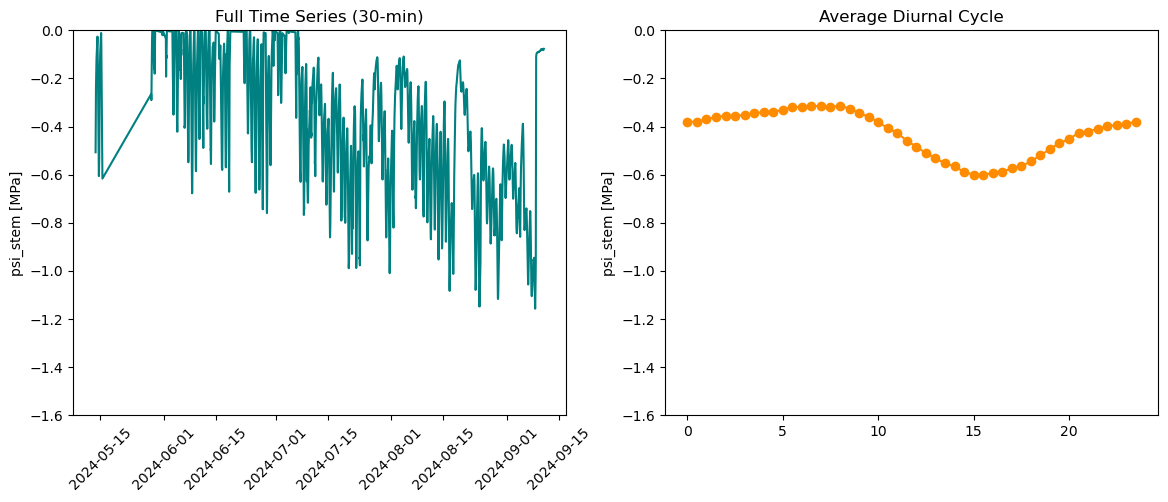

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


ax1.plot(resampled_df.index, resampled_df['psi'], color='teal')
ax1.set_ylim(-1.6, 0)
ax1.set_ylabel("psi_stem [MPa]")
ax1.set_title("Full Time Series (30-min)")
ax1.tick_params(axis='x', rotation=45)


ax2.plot(np.arange(0,24, 0.5), average_day['psi'], marker='o', color='darkorange')
ax2.set_ylim(-1.6, 0)
ax2.set_ylabel("psi_stem [MPa]")
ax2.set_title("Average Diurnal Cycle")


In [30]:
resampled_df.to_csv("/Net/Groups/BSI/work_scratch/ppapastefanou/data/Fluxnet_detail/eval_processed/psi_stem_2024_flora.csv")
